In [ ]:
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.applications import ResNet50
from keras.applications.resnet import preprocess_input
from keras.models import Sequential
from keras.layers import Dense , Dropout
from keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

[]


## Constant Variables

In [ ]:
TRAIN_PATH = r"Data\seg_train" # For Training
TEST_PATH = r"Data\seg_test" # For Validation in Model while training
PRED_PATH = r"Data\seg_pred" # For testing the model in the end (Predict)
 
DATASETS = [TRAIN_PATH,TEST_PATH,PRED_PATH]


IMG_SIZE = (224,224)
CLASS_MODE = "categorical"
NUM_OF_CLASSES = 6
OUTPUT_ACTIV_LAYER = "softmax"

BATCH_SIZE_TRAIN = 100
BATCH_SIZE_VALIDATION = 16
BATCH_SIZE_PRED = 1


WEIGHTS_NAME = "imagenet"
POOLING = "avg"
INCLUDE_OUTPUT_LAYER = False
TRAINABLE = False

BRIGHTNESS_RANGE = [0.8,1.2]
ZOOM_RANGE , SHEAR_RANGE = 0.2 , 0.2
HORIZENTAL_FLIP = True

EPOCHS = 10
METRIC = ["accuracy"]

LABELS = {Class_Name : Label for Label,Class_Name in enumerate(os.listdir(TRAIN_PATH))}
LABELS

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [161]:
def Calc_len_of_images(all_path:list):
    Sum = 0
    Len_Result = {}
    for DataPath in all_path:
        Class_Len = {}
        for Class_Name in os.listdir(DataPath):
            if DataPath.split("\\")[-1] != "seg_pred":
                Class_Fol_Path = os.path.join(DataPath,Class_Name)
                images = os.listdir(Class_Fol_Path)
                Class_Len[Class_Name] = len(images)
                Sum += len(images)
                Len_Result[DataPath.split("\\")[-1]] = Class_Len
            else:
                images = os.listdir(DataPath)
                Sum += len(images)
                Len_Result[DataPath.split("\\")[-1]] = len(images)
                break


    return Len_Result , Sum

In [162]:
Len_Res , Sum = Calc_len_of_images(DATASETS)

print(f"seg_train: {Len_Res["seg_train"]}\n")
print(f"seg_test: {Len_Res["seg_test"]}\n")
print(f"seg_pred: {Len_Res["seg_pred"]} (Mixed Images)\n")
print(f"All Images Count Is : {Sum}")

# Not Enough Images so we will use Transfare Learning

seg_train: {'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382}

seg_test: {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}

seg_pred: 7301 (Mixed Images)

All Images Count Is : 24335


In [163]:
def count_all_sizes(Path:list):
    all_sizes = {}
    for DataPath in Path:
        Image_Sizes = []
        for Class_Name in os.listdir(DataPath):
            if DataPath.split("\\")[-1] != "seg_pred":
                Class_Fol_Path = os.path.join(DataPath,Class_Name)
                images = os.listdir(Class_Fol_Path)
                for image in images:
                    Image_Sizes.append(mpimg.imread(os.path.join(Class_Fol_Path,image)).shape)
                
                all_sizes[DataPath.split("\\")[-1]] = Image_Sizes

    return all_sizes

In [164]:
all_sizes = count_all_sizes([TRAIN_PATH,TEST_PATH])
print(f"Seg_train Image Sizes = {set(all_sizes["seg_train"])}")
print(f"Seg_test Image Sizes = {set(all_sizes["seg_test"])}")

Seg_train Image Sizes = {(143, 150, 3), (131, 150, 3), (144, 150, 3), (103, 150, 3), (81, 150, 3), (150, 150, 3), (113, 150, 3), (140, 150, 3), (124, 150, 3), (102, 150, 3), (100, 150, 3), (136, 150, 3), (134, 150, 3), (149, 150, 3), (76, 150, 3), (115, 150, 3), (110, 150, 3), (108, 150, 3), (135, 150, 3), (133, 150, 3), (145, 150, 3), (111, 150, 3), (123, 150, 3), (146, 150, 3), (105, 150, 3), (147, 150, 3), (141, 150, 3), (119, 150, 3), (97, 150, 3), (142, 150, 3), (120, 150, 3)}
Seg_test Image Sizes = {(76, 150, 3), (149, 150, 3), (131, 150, 3), (72, 150, 3), (81, 150, 3), (141, 150, 3), (110, 150, 3), (150, 150, 3)}


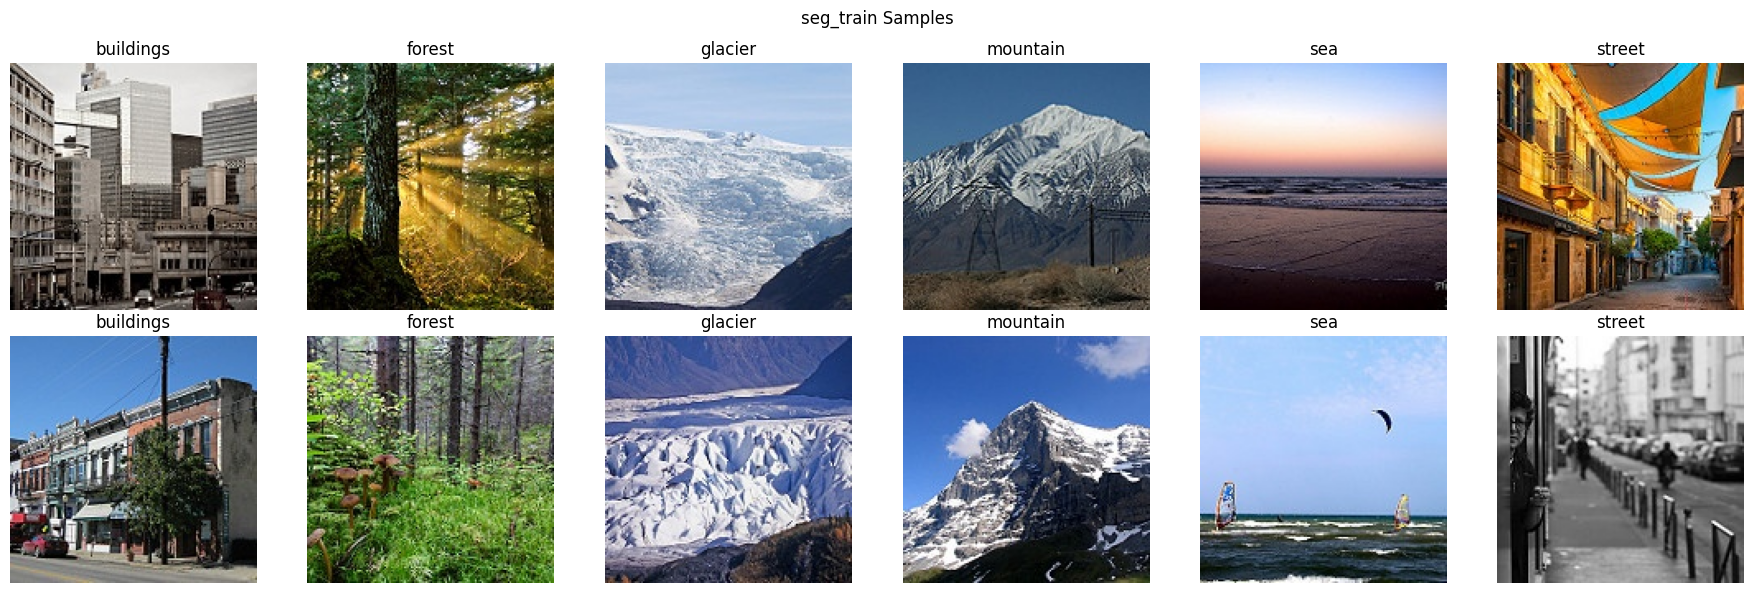

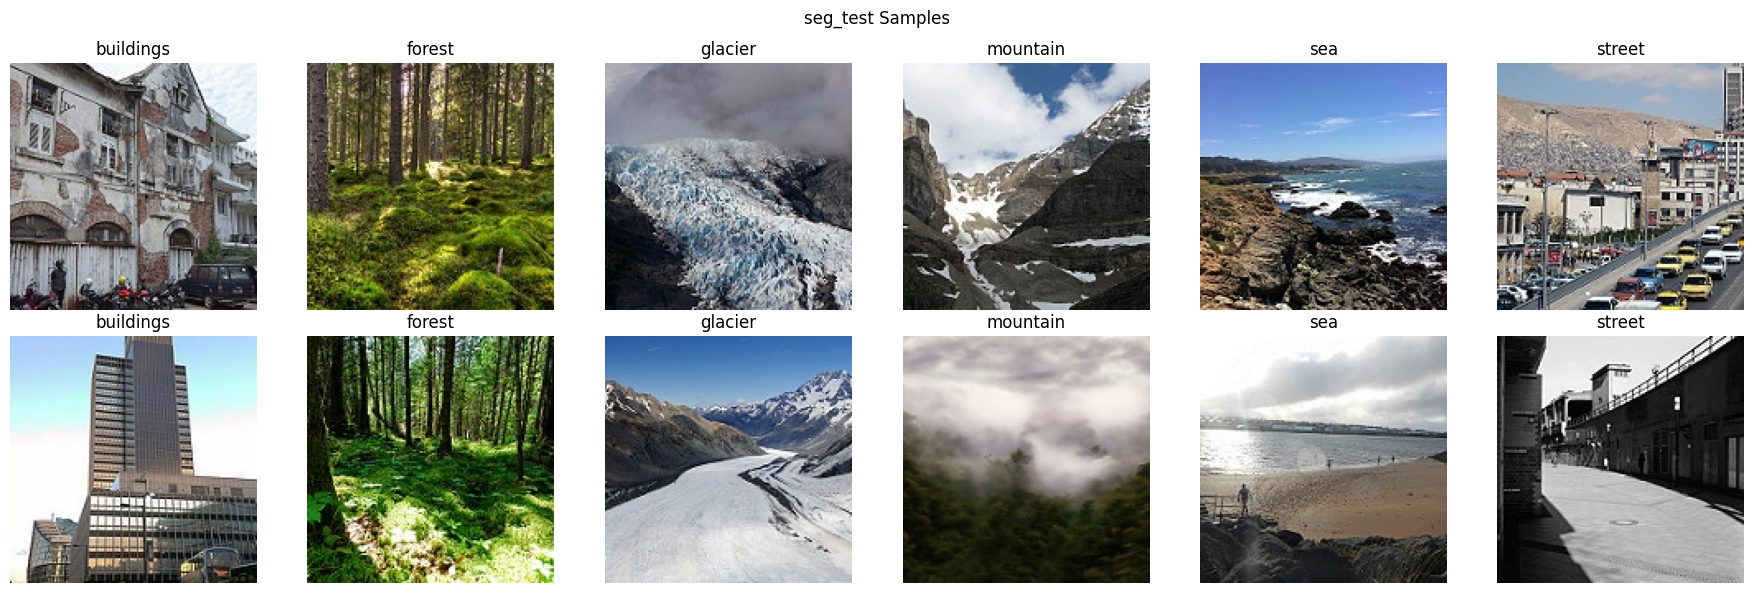

In [165]:

for DataPath in [TRAIN_PATH,TEST_PATH]:
    fig, axes = plt.subplots(2, len(os.listdir(DataPath)), figsize=(3 * len(os.listdir(DataPath)), 6))

    for i, class_name in enumerate(os.listdir(DataPath)):
        class_folder = os.path.join(DataPath, class_name)
        imgs = random.choices(os.listdir(class_folder), k=2)
        for j, img_file in enumerate(imgs):
            img = mpimg.imread(os.path.join(class_folder, img_file))
            axes[j, i].imshow(img)
            axes[j, i].set_title(f"{class_name}")
            axes[j, i].axis('off')

    plt.suptitle(f"{DataPath.split("\\")[-1]} Samples")
    plt.tight_layout()
    plt.show()

In [166]:
Data_Train_gen = ImageDataGenerator(preprocessing_function=preprocess_input,rescale=1./255)#brightness_range=BRIGHTNESS_RANGE,horizontal_flip=HORIZENTAL_FLIP,shear_range=SHEAR_RANGE,zoom_range=ZOOM_RANGE,rescale=1./255)
Data_Test_gen = ImageDataGenerator(preprocessing_function=preprocess_input,rescale=1./255)
Data_Pred_gen = ImageDataGenerator(preprocessing_function=preprocess_input,rescale=1./255)

In [167]:
Train_gen = Data_Train_gen.flow_from_directory(
                directory=  TRAIN_PATH,
                target_size=IMG_SIZE,
                class_mode=CLASS_MODE,
                batch_size=BATCH_SIZE_TRAIN,
                )


Validation_gen = Data_Test_gen.flow_from_directory(
                directory=  TEST_PATH,
                target_size=IMG_SIZE,
                class_mode=CLASS_MODE,
                batch_size=BATCH_SIZE_VALIDATION,
                )


PRED_DF = pd.DataFrame({"FileName": os.listdir(PRED_PATH)})

Pred_gen = Data_Pred_gen.flow_from_dataframe(
                                            dataframe=PRED_DF,
                                            directory=  PRED_PATH,
                                            x_col="FileName", y_col=None,
                                            target_size=IMG_SIZE,
                                            batch_size=BATCH_SIZE_PRED,
                                            class_mode=None,
                                            shuffle=False
                                                            )

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Found 7301 validated image filenames.


In [168]:
model = Sequential([ResNet50(include_top=INCLUDE_OUTPUT_LAYER,weights=WEIGHTS_NAME,pooling=POOLING),
                    Dropout(0.3),
                    Dense(NUM_OF_CLASSES,activation=OUTPUT_ACTIV_LAYER)])

model.layers[0].trainable = TRAINABLE

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [169]:
model.compile("adam",loss="categorical_crossentropy",metrics=METRIC)

In [170]:
CALLBACKS = [EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)]

In [ ]:
Fit_History = model.fit(Train_gen,
                        validation_data=Validation_gen,
                        verbose=1,
                        epochs=EPOCHS,
                        callbacks=CALLBACKS
                        )

In [ ]:
plt.plot(Fit_History.history['loss'])
plt.plot(Fit_History.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
plt.plot(Fit_History.history['accuracy'])
plt.plot(Fit_History.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()